## Resume Scanner
Owen Lee and Ben Schrager

# SWE Resume Reviewer

This project analyzes a software engineering applicant dataset to predict the likelihood that an applicant is hired.

## Research Question

Can we use applicant features to predict the likelihood that a software engineering applicant is hired?

## Supporting Questions

1. Which applicant features matter most in predicting hiring outcomes?

2. Can we turn the prediction into a simple resume-style evaluator for users?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('stackoverflow_full.csv')
df = df.rename(columns={"Unnamed: 0": "ApplicantID"})
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (73462, 15)

Columns:
['ApplicantID', 'Age', 'Accessibility', 'EdLevel', 'Employment', 'Gender', 'MentalHealth', 'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary', 'HaveWorkedWith', 'ComputerSkills', 'Employed']

Data types:
ApplicantID         int64
Age                   str
Accessibility         str
EdLevel               str
Employment          int64
Gender                str
MentalHealth          str
MainBranch            str
YearsCode           int64
YearsCodePro        int64
Country               str
PreviousSalary    float64
HaveWorkedWith        str
ComputerSkills      int64
Employed            int64
dtype: object

Missing values:
ApplicantID        0
Age                0
Accessibility      0
EdLevel            0
Employment         0
Gender             0
MentalHealth       0
MainBranch         0
YearsCode          0
YearsCodePro       0
Country            0
PreviousSalary     0
HaveWorkedWith    63
ComputerSkills     0
Employed           0
dtype: int6

In [5]:
df.head()
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))

print(df["Employed"].value_counts())
print(df["Employed"].value_counts(normalize=True))

target = "Employed"
id_cols = ["ApplicantID"]
numeric_cols = ["Employment", "YearsCode", "YearsCodePro", "PreviousSalary", "ComputerSkills"]
categorical_cols = ["Age", "Accessibility", "EdLevel", "Gender", "MentalHealth", "MainBranch", "Country"]
text_cols = ["HaveWorkedWith"]

df[numeric_cols].describe()
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))
df["HaveWorkedWith"].dropna().head(10)

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


--- ApplicantID ---
ApplicantID
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: count, dtype: int64

--- Age ---
Age
<35    47819
>35    25643
Name: count, dtype: int64

--- Accessibility ---
Accessibility
No     71355
Yes     2107
Name: count, dtype: int64

--- EdLevel ---
EdLevel
Undergraduate    37402
Master           18903
Other            10843
NoHigherEd        3706
PhD               2608
Name: count, dtype: int64

--- Employment ---
Employment
1    64874
0     8588
Name: count, dtype: int64

--- Gender ---
Gender
Man          68573
Woman         3518
NonBinary     1371
Name: count, dtype: int64

--- MentalHealth ---
MentalHealth
No     56944
Yes    16518
Name: count, dtype: int64

--- MainBranch ---
MainBranch
Dev       67396
NotDev     6066
Name: count, dtype: int64

--- YearsCode ---
YearsCode
10    6345
8     4606
7     4500
6     4384
5     4204
15    4142
12    3872
20    3697
9     3116
4     2848
Name: count, dtype: int64

--- YearsCodePro ---

HaveWorkedWith    0.085759
ApplicantID       0.000000
Age               0.000000
Accessibility     0.000000
EdLevel           0.000000
Employment        0.000000
Gender            0.000000
MentalHealth      0.000000
MainBranch        0.000000
YearsCode         0.000000
YearsCodePro      0.000000
Country           0.000000
PreviousSalary    0.000000
ComputerSkills    0.000000
Employed          0.000000
dtype: float64

## Random Forest Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


target = "Employed"

baseline_features = [
    "EdLevel",
    "MainBranch",
    "YearsCode",
    "YearsCodePro",
    "PreviousSalary",
    "ComputerSkills"
]

X = df[baseline_features].copy()
y = df[target].copy()


categorical_features = ["EdLevel", "MainBranch"]
numeric_features = ["YearsCode", "YearsCodePro", "PreviousSalary", "ComputerSkills"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])


rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7710474375552985
Precision: 0.774468085106383
Recall: 0.8084782332783348
F1 Score: 0.7911077993045206
ROC-AUC: 0.8586005000865564

Confusion Matrix:
[[4959 1855]
 [1509 6370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      6814
           1       0.77      0.81      0.79      7879

    accuracy                           0.77     14693
   macro avg       0.77      0.77      0.77     14693
weighted avg       0.77      0.77      0.77     14693



In [15]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(15))

                       Feature  Importance
3          num__ComputerSkills    0.556953
2          num__PreviousSalary    0.222428
0               num__YearsCode    0.102490
1            num__YearsCodePro    0.089455
10      cat__MainBranch_NotDev    0.006342
9          cat__MainBranch_Dev    0.005657
7             cat__EdLevel_PhD    0.005347
4          cat__EdLevel_Master    0.003644
8   cat__EdLevel_Undergraduate    0.003159
6           cat__EdLevel_Other    0.002816
5      cat__EdLevel_NoHigherEd    0.001709


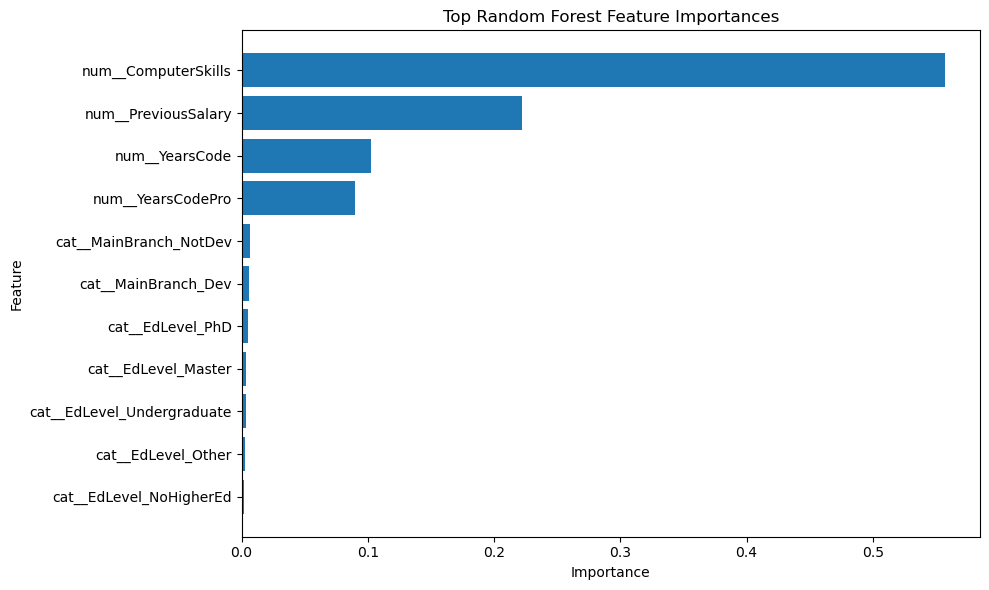

In [8]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

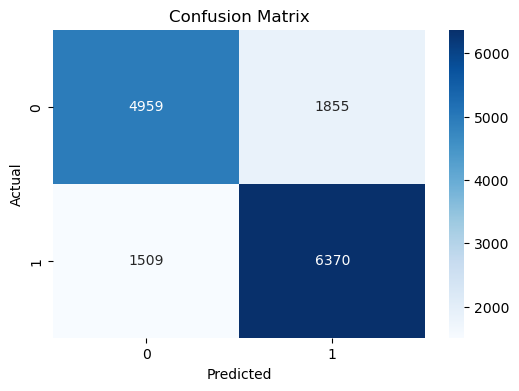

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Our initial random forest achieved 77.1% accuracy and 0.859 ROC-AUC, indicating that applicant characteristics contain substantial predictive information about hiring outcomes. The model relied most heavily on ComputerSkills, followed by PreviousSalary, YearsCode, and YearsCodePro, while education level and main branch contributed relatively little in this baseline version.

In [16]:
y_train_pred = rf_model.predict(X_train)
y_train_proba = rf_model.predict_proba(X_train)[:, 1]

print("TRAIN Accuracy:", accuracy_score(y_train, y_train_pred))
print("TRAIN F1:", f1_score(y_train, y_train_pred))
print("TRAIN ROC-AUC:", roc_auc_score(y_train, y_train_proba))

y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_proba))

TRAIN Accuracy: 0.9184774285762902
TRAIN F1: 0.9248859413950425
TRAIN ROC-AUC: 0.9822106555397663
TEST Accuracy: 0.7710474375552985
TEST F1: 0.7911077993045206
TEST ROC-AUC: 0.8586005093997103


## Logistic Regression

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# baseline features
baseline_features = [
    "EdLevel",
    "MainBranch",
    "YearsCode",
    "YearsCodePro",
    "PreviousSalary",
    "ComputerSkills"
]

X = df[baseline_features].copy()
y = df["Employed"].copy()

categorical_features = ["EdLevel", "MainBranch"]
numeric_features = ["YearsCode", "YearsCodePro", "PreviousSalary", "ComputerSkills"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

log_model.fit(X_train, y_train)

y_train_pred = log_model.predict(X_train)
y_train_proba = log_model.predict_proba(X_train)[:, 1]

y_test_pred = log_model.predict(X_test)
y_test_proba = log_model.predict_proba(X_test)[:, 1]

print("TRAIN Accuracy:", accuracy_score(y_train, y_train_pred))
print("TRAIN F1:", f1_score(y_train, y_train_pred))
print("TRAIN ROC-AUC:", roc_auc_score(y_train, y_train_proba))

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST Precision:", precision_score(y_test, y_test_pred))
print("TEST Recall:", recall_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

TRAIN Accuracy: 0.7832871071483265
TRAIN F1: 0.797571364994596
TRAIN ROC-AUC: 0.8716214191671084
TEST Accuracy: 0.7879262233716736
TEST Precision: 0.8038790353451576
TEST Recall: 0.799593857088463
TEST F1: 0.8017307202850598
TEST ROC-AUC: 0.8740212294458232

Confusion Matrix:
[[5277 1537]
 [1579 6300]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77      6814
           1       0.80      0.80      0.80      7879

    accuracy                           0.79     14693
   macro avg       0.79      0.79      0.79     14693
weighted avg       0.79      0.79      0.79     14693



We compared a random forest classifier and a logistic regression model on the same baseline feature set. Although the random forest achieved strong training performance, it showed substantial overfitting and lower test-set performance. Logistic regression generalized better, with higher test accuracy, F1 score, and ROC-AUC, making it the stronger baseline model for our project.